# Image convolution and deconvolution with FFT

This notebook demonstrates convolution and deconvolution of 3D images using FFT-based
operations in `pyclesperanto`. Deconvolution is performed with the Richardson-Lucy
algorithm, adapted from the [clij2-fft](https://github.com/clij/clij2-fft/tree/master)
repository.


In [1]:
import numpy as np
from skimage.io import imread
import matplotlib.pyplot as plt
import pyclesperanto as cle

cle.select_device()


(OpenCL) Apple M5 Max (OpenCL 1.2)
	Vendor:                      Apple
	Driver Version:              1.2 1.0
	Device Type:                 GPU
	Compute Units:               40
	Global Memory Size:          53084 MB
	Local Memory Size:           0 MB
	Maximum Buffer Size:         9953 MB
	Max Clock Frequency:         1000 MHz
	Image Support:               Yes

## Load images, PSF, and ground truth

We demonstrate the pipeline using synthetic data: a noise-free image, a noisy image, a
point spread function (PSF), and the ground truth used to generate them.


In [2]:
data_folder = '../data/deconv'

image = imread(f'{data_folder}/Bars-G10-P30-stack.tif').astype(np.float32)
image_noisy = imread(f'{data_folder}/Bars-G10-P15-stack.tif').astype(np.float32)
psf = imread(f'{data_folder}/PSF-Bars-stack.tif').astype(np.float32)
truth = imread(f'{data_folder}/Bars-stack.tif').astype(np.float32)


Since we are working with 3D stacks, we display each volume as three maximum-intensity
projections (xy, xz, yz). We define a small helper function to avoid repeating this
plotting code.


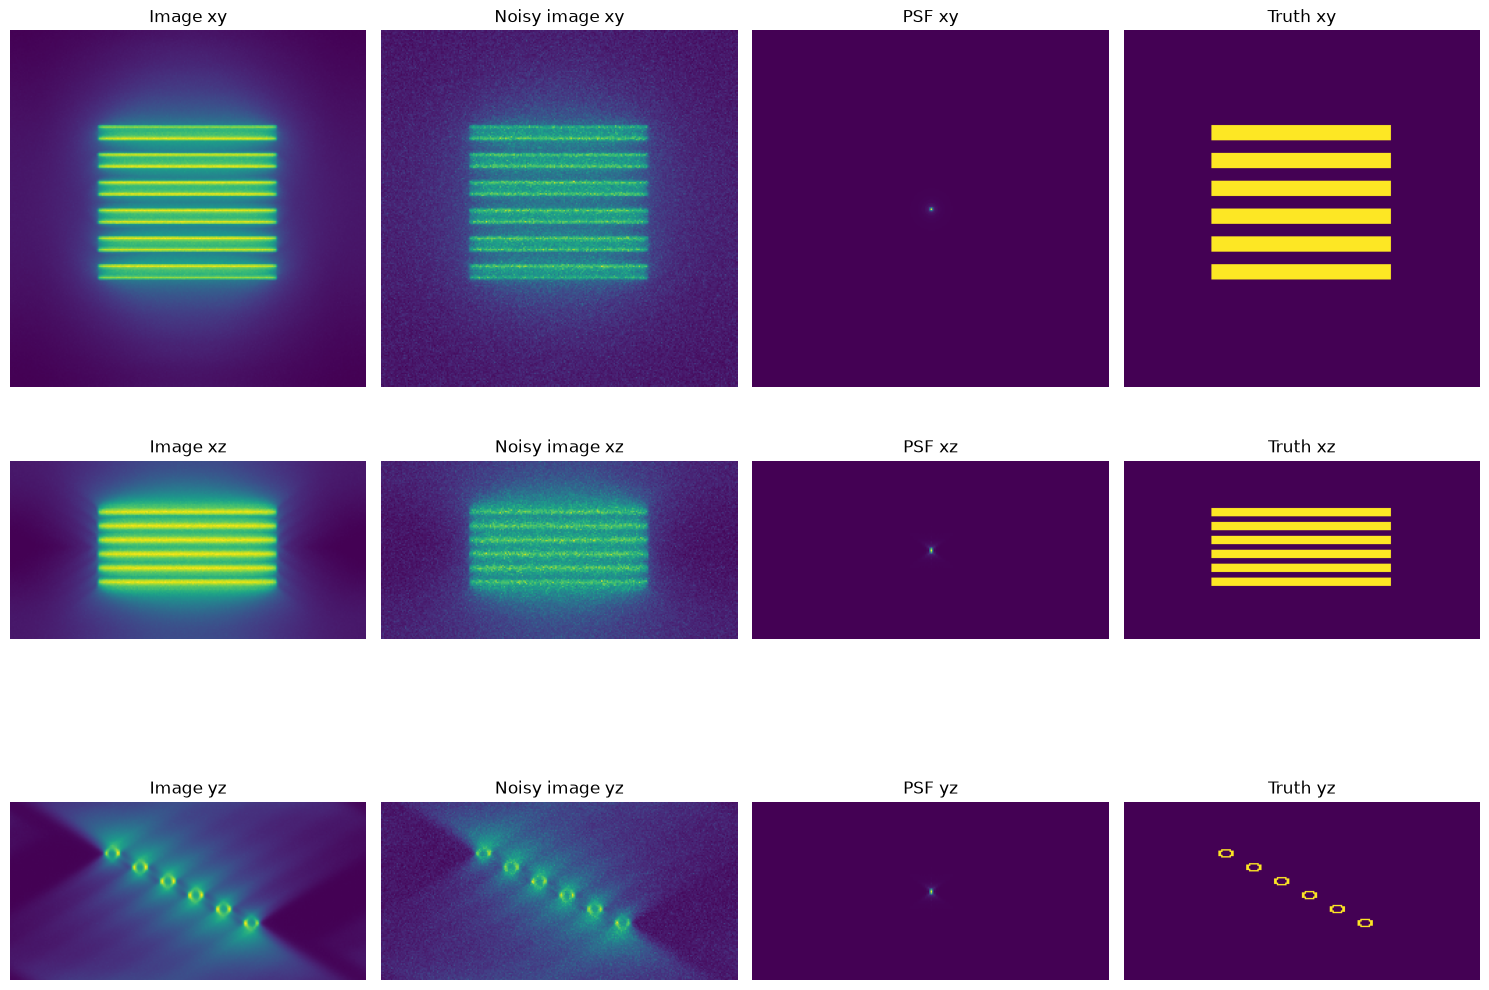

In [3]:
def show_mips(images, titles, figsize=(15, 11)):
    """Plot maximum-intensity projections (xy, xz, yz) for a list of 3D volumes."""
    fig, axs = plt.subplots(3, len(images), figsize=figsize)
    for col, (vol, title) in enumerate(zip(images, titles)):
        vol = np.asarray(vol)
        axs[0, col].imshow(vol.max(axis=0))
        axs[0, col].set_title(f'{title} xy')
        axs[1, col].imshow(vol.max(axis=1))
        axs[1, col].set_title(f'{title} xz')
        axs[2, col].imshow(vol.max(axis=2))
        axs[2, col].set_title(f'{title} yz')
    for ax in axs.ravel():
        ax.axis('off')
    plt.tight_layout()
    plt.show()


show_mips([image, image_noisy, psf, truth], ['Image', 'Noisy image', 'PSF', 'Truth'])


## Convolution

Convolving an image with a PSF kernel mimics the blurring introduced when observing a
sample under a microscope. `cle.fft.convolve()` performs this operation in the
frequency domain via FFT. It takes care of two requirements automatically:
- padding the kernel to the same size as the image,
- centering the kernel at `(0, 0, 0)`.

We first try it on a small 2D example: a 3x3 array convolved with a 3x3 kernel.


In [4]:
input_np = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8]], dtype=np.float32)
kernel_np = np.ones((3, 3), dtype=np.float32)

output_gpu = cle.fft.convolve(cle.push(input_np), cle.push(kernel_np), None, correlate=False)
print(cle.pull(output_gpu))


[[36. 36. 36.]
 [36. 36. 36.]
 [36. 36. 36.]]


Now let's apply a similar (normalized) averaging kernel to a crop of the `blobs.png`
sample image, which is equivalent to a mean filter applied in the frequency domain.


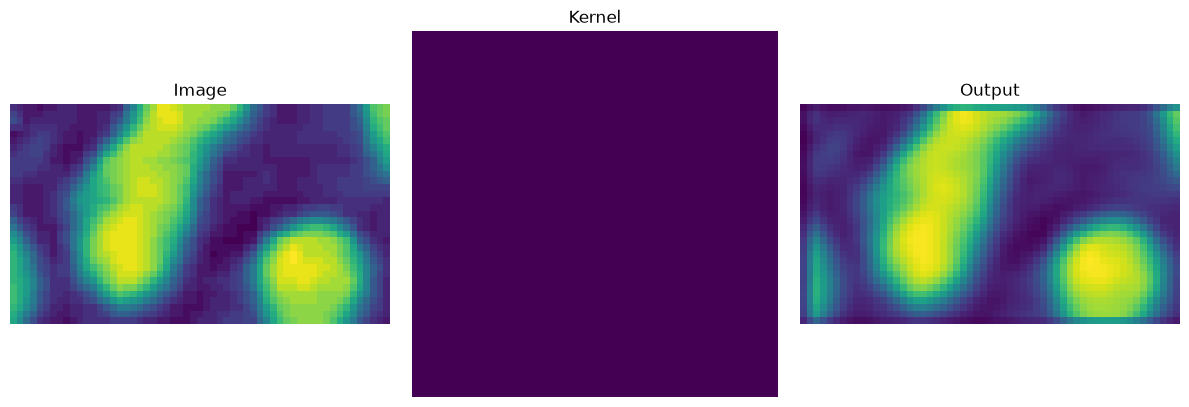

In [5]:
blobs = cle.push(imread('https://samples.fiji.sc/blobs.png').squeeze().astype(np.float32)[:33, :57])
kernel_np = np.ones((3, 3), dtype=np.float32) / 9

output_gpu = cle.fft.convolve(blobs, cle.push(kernel_np), None, correlate=False)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(cle.pull(blobs))
axs[0].set_title('Image')
axs[1].imshow(kernel_np)
axs[1].set_title('Kernel')
axs[2].imshow(cle.pull(output_gpu))
axs[2].set_title('Output')
for ax in axs:
    ax.axis('off')
plt.tight_layout()
plt.show()


Instead of a plain averaging kernel, we can convolve the ground truth volume with a
realistic microscope PSF to simulate how it would look after being imaged, and compare
the result to the actual (real) acquired image.


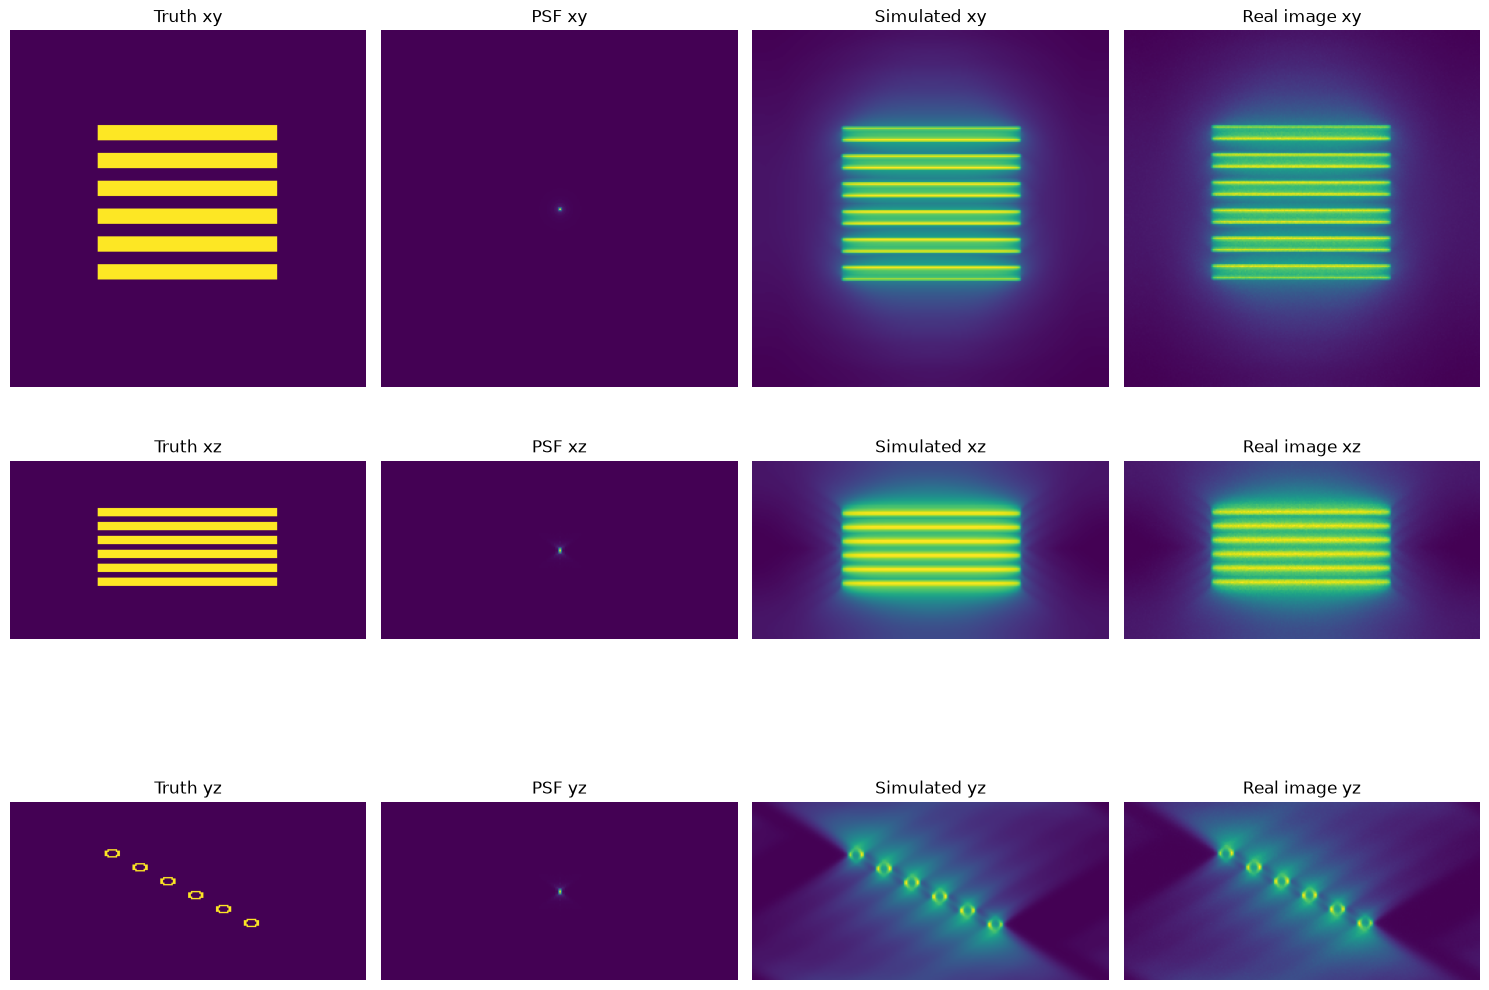

In [6]:
output_gpu = cle.fft.convolve(cle.push(truth), cle.push(psf), None, correlate=False)
output_np = cle.pull(output_gpu)

show_mips([truth, psf, output_np, image], ['Truth', 'PSF', 'Simulated', 'Real image'])


## Deconvolution

Deconvolution is the inverse process: given an acquired image and the microscope's PSF,
we try to reconstruct the original, unblurred sample. `cle.fft.deconvolve()` implements
the iterative Richardson-Lucy algorithm, with an optional regularization parameter
(Total Variation regularization) that improves robustness to noise.

We compare deconvolution with and without regularization on the noise-free image.


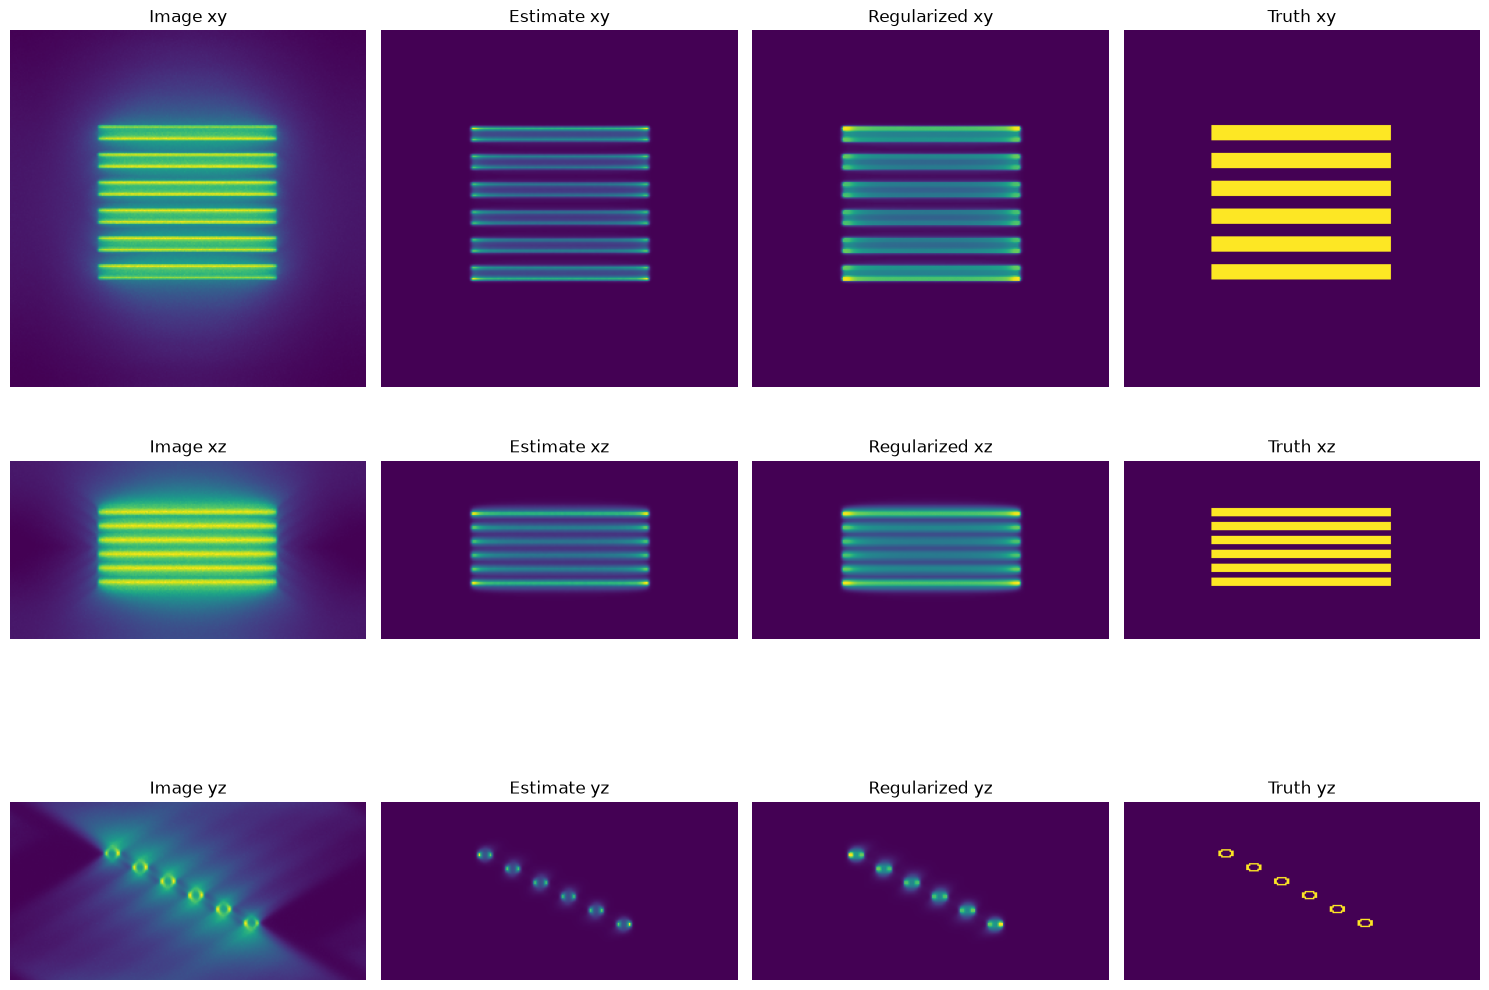

In [7]:
input_gpu = cle.push(image)
psf_gpu = cle.push(psf)

estimate = cle.pull(cle.fft.deconvolve(input_gpu, psf_gpu, None, None, 100, 0))
estimate_reg = cle.pull(cle.fft.deconvolve(input_gpu, psf_gpu, None, None, 100, 0.004))

show_mips([image, estimate, estimate_reg, truth], ['Image', 'Estimate', 'Regularized', 'Truth'])


The regularization term helps most on noisy data, where it improves the smoothness of
the reconstruction. Let's repeat the deconvolution on the noisy image.


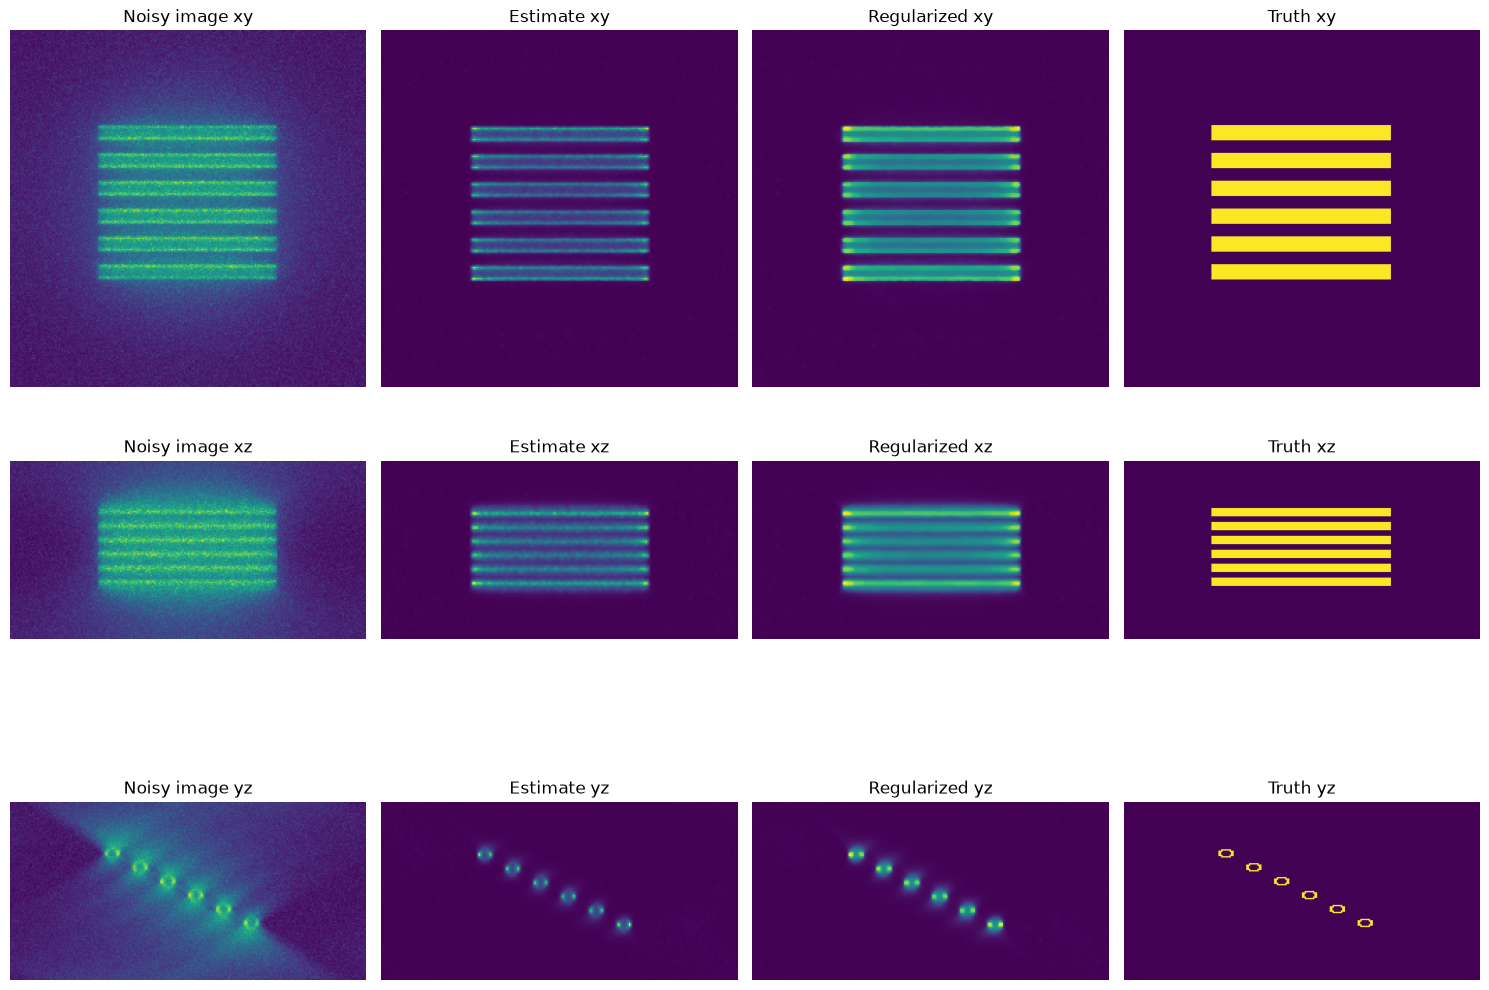

In [8]:
input_gpu = cle.push(image_noisy)

estimate = cle.pull(cle.fft.deconvolve(input_gpu, psf_gpu, None, None, 100, 0))
estimate_reg = cle.pull(cle.fft.deconvolve(input_gpu, psf_gpu, None, None, 100, 0.004))

show_mips([image_noisy, estimate, estimate_reg, truth], ['Noisy image', 'Estimate', 'Regularized', 'Truth'])


> Note:
> Without regularization, the Richardson-Lucy estimate tends to amplify noise as
> iterations increase; the regularized version trades off some sharpness for a smoother,
> less noisy reconstruction.
